In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [6]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [8]:
df["area_type"].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


In [9]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [10]:
df.dropna(inplace = True)

In [11]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
society,0
total_sqft,0
bath,0
balcony,0
price,0


In [12]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '3 Bedroom', '1 RK', '4 BHK',
       '1 BHK', '5 BHK', '11 BHK', '5 Bedroom', '9 BHK', '2 Bedroom',
       '6 BHK', '7 BHK', '6 Bedroom'], dtype=object)

In [13]:
df['bedrooms'] = df['size'].apply(lambda x: int(x.split(" ")[0]))

In [14]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00,2
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5.0,3.0,295.00,4


In [15]:
df.drop(columns = 'size', inplace = True)

In [16]:
df['bedrooms'].unique()

array([ 2,  4,  3,  1,  5, 11,  9,  6,  7])

In [17]:
def convert_sqft_to_num(x):
  if isinstance(x, float):
        return x
  tokens = x.split('-')
  if len(tokens) == 2:
      try:
        return (float(tokens[0].strip())+float(tokens[1].strip()))/2
      except:
        return None
  try:
      return float(x)
  except:
      return None

In [18]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)
df.dropna(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7481 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     7481 non-null   object 
 1   availability  7481 non-null   object 
 2   location      7481 non-null   object 
 3   society       7481 non-null   object 
 4   total_sqft    7481 non-null   float64
 5   bath          7481 non-null   float64
 6   balcony       7481 non-null   float64
 7   price         7481 non-null   float64
 8   bedrooms      7481 non-null   int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 584.5+ KB


{'whiskers': [<matplotlib.lines.Line2D at 0x7d0679dbe210>,
 'caps': [<matplotlib.lines.Line2D at 0x7d0679dbe810>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d0679d83170>],
 'medians': [<matplotlib.lines.Line2D at 0x7d0679dbede0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d0679dbf0b0>],
 'means': []}

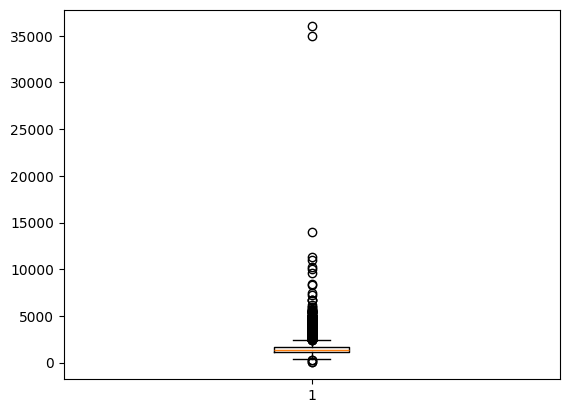

In [19]:
plt.boxplot(df['total_sqft'])  # the  box in the graph represents the 25-75 perc of the points. THe orange line is 50 perc line

In [20]:
df['total_sqft'].describe()

,total_sqft
count,7481.000000
mean,1507.516043
std,935.083274
min,11.000000
25%,1115.000000
50%,1310.000000
75%,1656.000000
max,36000.000000


In [21]:
low, high = df['total_sqft'].quantile([0.1, 0.9])
mask_area = df['total_sqft'].between(low, high)
df = df[mask_area]

{'whiskers': [<matplotlib.lines.Line2D at 0x7d067a956840>,
 'caps': [<matplotlib.lines.Line2D at 0x7d067a956e10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d067a956660>],
 'medians': [<matplotlib.lines.Line2D at 0x7d067a957410>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d067a957740>],
 'means': []}

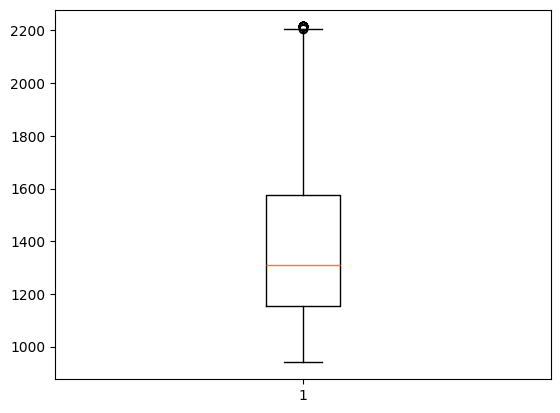

In [22]:
plt.boxplot(df['total_sqft'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7d067a9bfad0>,
 'caps': [<matplotlib.lines.Line2D at 0x7d067a9bff50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d0679d666c0>],
 'medians': [<matplotlib.lines.Line2D at 0x7d067a9ec500>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d067a9ec7d0>],
 'means': []}

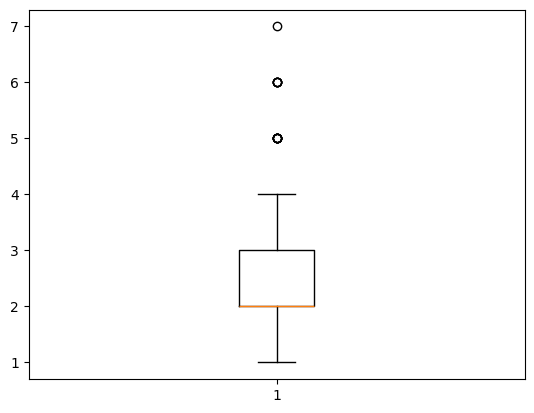

In [23]:
plt.boxplot(df['bath'])

In [24]:
df['bath'].describe()

,bath
count,6002.000000
mean,2.373709
std,0.566929
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,7.000000


In [25]:
df['bath'].value_counts()

,count
bath,
2.0,3929
3.0,1861
4.0,177
1.0,21
5.0,8
6.0,5
7.0,1


In [26]:
low, high = df['bath'].quantile([0.1, 0.8])
mask_area = df['bath'].between(low, high)
df = df[mask_area]

In [27]:
df['bath'].value_counts()

,count
bath,
2.0,3929
3.0,1861


{'whiskers': [<matplotlib.lines.Line2D at 0x7d067a832ab0>,
 'caps': [<matplotlib.lines.Line2D at 0x7d067a833050>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d067a8327b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7d067a833560>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d067a8337d0>],
 'means': []}

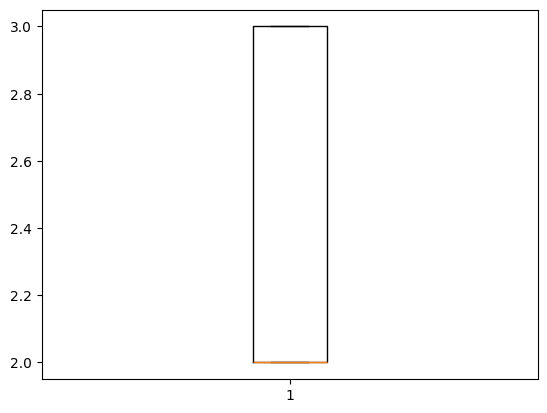

In [28]:
plt.boxplot(df['bath'])

In [29]:
df.location = df.location.apply(lambda x: x.strip())
location_stats = df['location'].value_counts(ascending = False)
location_stats

,count
location,
Whitefield,283
Sarjapur Road,230
Electronic City,175
Kanakpura Road,164
Thanisandra,163
...,...
Aishwarya Crystal Layout,1
Virupakshapura,1
Kenchenhalli,1


In [30]:
df['location'] = df['location'].where(
    df['location'].map(location_stats) > 10,
    'other'
)

In [31]:
df.head(10)

,area_type,availability,location,society,total_sqft,bath,balcony,price,bedrooms
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3
5,Super built-up Area,Ready To Move,Whitefield,DuenaTa,1170.0,2.0,1.0,38.00,2
12,Super built-up Area,Ready To Move,7th Phase JP Nagar,Shncyes,1000.0,2.0,1.0,38.00,2
15,Super built-up Area,Ready To Move,Mysore Road,PrntaEn,1175.0,2.0,2.0,73.50,2
16,Super built-up Area,Ready To Move,Bisuvanahalli,Prityel,1180.0,3.0,2.0,48.00,3
17,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,GrrvaGr,1540.0,3.0,3.0,60.00,3
21,Super built-up Area,19-Dec,Binny Pete,She 2rk,1755.0,3.0,1.0,122.00,3
28,Super built-up Area,17-Oct,Ramagondanahalli,ViistLa,1151.0,2.0,2.0,48.77,2
29,Super built-up Area,Ready To Move,Electronic City,KBityo,1025.0,2.0,1.0,47.00,3


<Axes: >

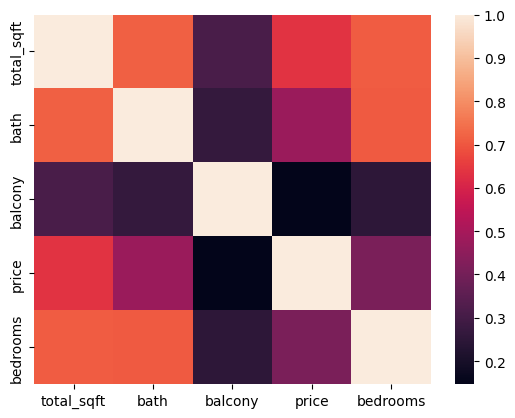

In [32]:
corr = df.select_dtypes("number").corr()
sns.heatmap(corr)

In [33]:
df.drop(columns = ['area_type','society','balcony','availability'], inplace=True) # From heatmap, it's evident that price does not depend heavily on balcony count

In [34]:
!pip install -q category_encoders

In [35]:
from category_encoders import OneHotEncoder

In [36]:
x = df.drop(['price'],axis = 'columns')

In [37]:
y = df.price

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size = 0.2, random_state = 10)

In [40]:
model = make_pipeline(OneHotEncoder(), LinearRegression())
model.fit(x_train, y_train)

Pipeline(steps=[('onehotencoder', OneHotEncoder(cols=['location'])),
                ('linearregression', LinearRegression())])

In [41]:
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred)
mae

15.97861340556071

In [42]:
from sklearn.metrics import mean_absolute_percentage_error as error
mae = error(y_test, y_pred)
mae

0.21464085202678912

In [43]:
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact

In [44]:
location_options = sorted(
    df['location'].dropna().unique()
)

sqft_min = float(df['total_sqft'].min())
sqft_max = float(df['total_sqft'].max())

bath_min = float(df['bath'].min())
bath_max = float(df['bath'].max())

bedroom_min = float(df['bedrooms'].min())
bedroom_max = float(df['bedrooms'].max())

In [45]:
def predict_price(input_data: dict):
    input_df = pd.DataFrame([input_data])
    return model.predict(input_df)[0]

# example_house = {
#     'location': 'Whitefield',
#     'total_sqft': 1200,
#     'bath': 2,
#     'bedrooms':2
# }

# print("Predicted Price:", predict_price(example_house))


In [46]:
def predict_from_widget(location, total_sqft, bath, bedrooms):
    input_data = {
        'location': location,
        'total_sqft': total_sqft,
        'bath': bath,
        'bedrooms': bedrooms
    }

    price = predict_price(input_data)
    print(f"Predicted Price: {price:.2f} Lakhs")

In [47]:
interact(
    predict_from_widget,
    location=Dropdown(
        options=location_options,
        description='Location'
    ),
    total_sqft=FloatSlider(
        min=sqft_min,
        max=sqft_max,
        step=50,
        value=1200,
        description='Sqft'
    ),
    bath=IntSlider(
        min=bath_min,
        max=bath_max,
        value=2,
        description='Bath'
    ),
    bedrooms=IntSlider(
        min=bedroom_min,
        max=bedroom_max,
        value=2,
        description='Bedrooms'
    )
)

interactive(children=(Dropdown(description='Location', options=('5th Phase JP Nagar', '7th Phase JP Nagar', '8…

<function __main__.predict_from_widget(location, total_sqft, bath, bedrooms)>